In [1]:
import minari
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# 1. A more robust, memory-aware custom Dataset class
class MinariObsDataset(Dataset):
    """Custom PyTorch Dataset for Minari observations."""
    def __init__(self, dataset_name):
        # Note: This still loads all observations into RAM. For extremely large datasets,
        # a more advanced approach would index directly into the source HDF5 file.
        print(f"Loading Minari dataset '{dataset_name}'...")
        dataset = minari.load_dataset(dataset_name)
        self.observations = np.vstack([e.observations for e in dataset.iterate_episodes()])
        
        # The ToTensor transform handles scaling to [0,1] and dimension permutation (H,W,C -> C,H,W)
        self.transform = transforms.ToTensor()
        print("Dataset loaded and observations extracted.")

    def __len__(self):
        return len(self.observations)

    def __getitem__(self, idx):
        obs = self.observations[idx]
        return self.transform(obs)

# 2. Instantiate the dataset
full_dataset = MinariObsDataset('Box2D/CarRacing-v3/expert-v0')
print(f"Total observations: {len(full_dataset)}")
print(f"Observation shape: {full_dataset[0].shape}")

# 3. Create a train/validation split (e.g., 90% train, 10% validation)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# 4. Create separate DataLoaders for training and validation
batch_size = 64
# Use num_workers > 0 for faster data loading if your system supports it
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("\nData preparation complete.")
print(f"Train DataLoader ready with {len(train_loader)} batches of size {batch_size}.")
print(f"Validation DataLoader ready with {len(val_loader)} batches of size {batch_size}.")

Loading Minari dataset 'Box2D/CarRacing-v3/expert-v0'...
Dataset loaded and observations extracted.
Total observations: 245743
Observation shape: torch.Size([3, 96, 96])
Training set size: 221168
Validation set size: 24575

Data preparation complete.
Train DataLoader ready with 3456 batches of size 64.
Validation DataLoader ready with 384 batches of size 64.


In [2]:
import torch
from tqdm import tqdm
from src.models.vae import VAE, vae_loss
from src.utils.loggers import WandBLogger

# --- Hyperparameters ---
epochs = 20
learning_rate = 1e-3
latent_dim = 32
beta = 1.0 # Weight for the KL divergence term

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Training on {device}...")

# MODIFICATION 1: Add a variable to track the best model
best_val_loss = float('inf')

# --- Training Loop ---
for epoch in range(epochs):
    # --- Training Phase ---
    model.train() # Set model to training mode
    train_loss = 0
    pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    
    for batch in pbar_train:
        # MODIFICATION 2: Correctly handle the data batch
        # Our custom dataset returns a single tensor, so `batch` is the data itself.
        data = batch.to(device)
        
        # Forward pass
        recon_batch, mu, log_var = model(data)
        
        # Calculate loss
        loss = vae_loss(recon_batch, data, mu, log_var, beta)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar_train.set_postfix({'loss': f"{loss.item() / len(data):.4f}"})

    avg_train_loss = train_loss / len(train_loader.dataset)

    # MODIFICATION 3: Add the crucial Validation Phase
    model.eval() # Set model to evaluation mode
    val_loss = 0
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
    with torch.no_grad(): # Disable gradient calculations for validation
        for batch in pbar_val:
            data = batch.to(device)
            recon_batch, mu, log_var = model(data)
            loss = vae_loss(recon_batch, data, mu, log_var, beta)
            val_loss += loss.item()
            pbar_val.set_postfix({'loss': f"{loss.item() / len(data):.4f}"})

    avg_val_loss = val_loss / len(val_loader.dataset)
    
    print(f"====> Epoch: {epoch+1} | Avg Train Loss: {avg_train_loss:.4f} | Avg Val Loss: {avg_val_loss:.4f}")

    # MODIFICATION 4: Save the best model based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'carracing_vae_best.pth')
        print(f"✨ New best model saved with validation loss: {best_val_loss:.4f}")

print("\nModel training complete.")
print(f"Best model saved to carracing_vae_best.pth with validation loss: {best_val_loss:.4f}")

Training on cuda...


====> Epoch: 1 | Avg Train Loss: 15185.9995 | Avg Val Loss: 15099.1255
✨ New best model saved with validation loss: 15099.1255


====> Epoch: 2 | Avg Train Loss: 15098.2565 | Avg Val Loss: 15087.2106
✨ New best model saved with validation loss: 15087.2106


====> Epoch: 3 | Avg Train Loss: 15090.3390 | Avg Val Loss: 15080.9228
✨ New best model saved with validation loss: 15080.9228


====> Epoch: 4 | Avg Train Loss: 15086.2799 | Avg Val Loss: 15079.3363
✨ New best model saved with validation loss: 15079.3363


...

====> Epoch: 16 | Avg Train Loss: 15075.3088 | Avg Val Loss: 15068.4800
✨ New best model saved with validation loss: 15068.4800


====> Epoch: 17 | Avg Train Loss: 15075.0680 | Avg Val Loss: 15067.9010
✨ New best model saved with validation loss: 15067.9010


====> Epoch: 18 | Avg Train Loss: 15074.9770 | Avg Val Loss: 15067.7637
✨ New best model saved with validation loss: 15067.7637


====> Epoch: 19 | Avg Train Loss: 15074.3171 | Avg Val Loss: 15067.8966


====> Epoch: 20 | Avg Train Loss: 15074.5043 | Avg Val Loss: 15067.2728
✨ New best model saved with validation loss: 15067.2728

Model training complete.
Best model saved to carracing_vae_best.pth with validation loss: 15067.2728


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
# Make sure the VAE class and full_dataset object are defined or loaded
# from our previous steps.
# from src.models.vae import VAE
# full_dataset = MinariObsDataset('Box2D/CarRacing-v3/expert-v0')

# --- 1. Load your BEST trained model ---
model = VAE(latent_dim=latent_dim)
# MODIFICATION 1: Load the model saved based on the best validation score
model.load_state_dict(torch.load('carracing_vae_best.pth'))
model.to(device)
model.eval() # Set the model to evaluation mode

# --- 2. Get a single observation and preprocess it CONSISTENTLY ---
# MODIFICATION 2: Reuse the dataset's transform for preprocessing.
# This is cleaner and guarantees consistency with the training data.
sample_idx = random.choice(range(len(full_dataset))) # Randomly select an index
# Get the raw numpy image for visualization later
sample_obs_np = full_dataset.observations[sample_idx] 
# Get the pre-processed tensor directly from our dataset
image_tensor = full_dataset[sample_idx] 
# Add the batch dimension and send to the correct device
image = image_tensor.unsqueeze(0).to(device)

# --- 3. Encode the image ---
with torch.no_grad(): # No need to calculate gradients
    mu, log_var = model.encode(image)

# The mean 'mu' is typically used as the final compressed representation
encoded_vector = mu.cpu().numpy().flatten()

print(f"Original image shape: {sample_obs_np.shape}")
print(f"Encoded vector shape: {encoded_vector.shape}")
print(f"Encoded vector (mu): \n{encoded_vector}") # Uncomment to see the vector

Original image shape: (96, 96, 3)
Encoded vector shape: (32,)
Encoded vector (mu): 
[-0.22516444  0.8624772  -0.20417324  1.3529278   0.94551724 -0.22325858
 -1.3401327  -0.08524591 -0.3048047  -0.07883866  0.42896485  1.2832978
 -0.02538888 -0.11253747  0.62396     0.00463211  0.23703934 -0.4549131
 -0.14552903 -0.75964874 -1.177284   -0.3289757  -2.3855958  -0.06922972
 -0.03759991  0.4128374  -0.06723498 -0.01017652 -0.49292615  0.45243183
  0.00475344  1.153553  ]


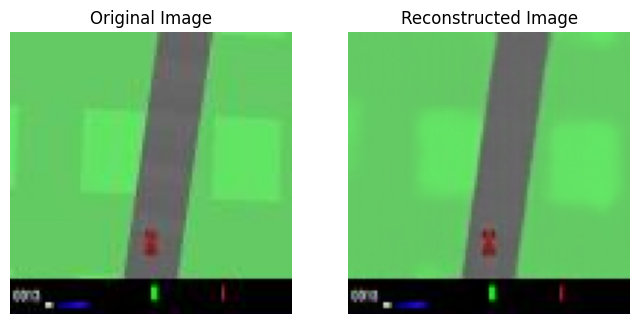

In [14]:
# --- 4. Decode the latent vector to visualize the reconstruction ---
with torch.no_grad():
    # We can use mu for a deterministic reconstruction
    reconstructed_image_tensor = model.decode(mu)

# Convert the output tensor back to a displayable image format (H, W, C)
reconstructed_image_np = reconstructed_image_tensor.cpu().squeeze(0).permute(1, 2, 0).numpy()

# --- 5. Display the results ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_obs_np)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(reconstructed_image_np)
axes[1].set_title("Reconstructed Image")
axes[1].axis('off')

plt.show()